In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.array as da

In [3]:
h5_location = r'C:\Users\formanj\GitHub\FISH_Processing\Demos\DUSP1_DexTimeConcSweep_10nM_75min_041223\DUSP1_DexTimeConcSweep_10nM_75min_041223.h5'
h5_file = h5py.File(h5_location, 'r')


In [4]:
level = 1

def print_group(name, obj):
    # Calculate current level based on the name depth
    current_level = name.count('/')
    if current_level <= level:
        print("  " * current_level + f"- {name}")

h5_file.visititems(print_group)

- Analysis_demo_2024-11-20
  - Analysis_demo_2024-11-20/df_cellresults
  - Analysis_demo_2024-11-20/df_clusterresults
  - Analysis_demo_2024-11-20/df_spotresults
  - Analysis_demo_2024-11-20/parameters
- masks
- metadata
- raw_images


In [6]:
pd.read_hdf(h5_location, key='Analysis_demo_2024-11-20/df_cellresults')

,cell_id,cell_area,nuc_area,nb_rna,nb_rna_in_nuc,nb_rna_out_nuc,nb_foci,nb_transcription_site,timepoint,fov,FISH_Channel
0,4,6278,6278,83,83,0,0,2,0,0,0
1,6,7312,7312,51,51,0,0,1,0,0,0
2,7,6774,6774,75,75,0,0,0,0,0,0
3,8,6797,6797,88,88,0,0,0,0,0,0
4,9,5769,5769,72,72,0,0,1,0,0,0
5,10,6718,6718,67,67,0,0,0,0,0,0
6,11,7246,7246,65,65,0,0,0,0,0,0
7,12,6748,6748,78,78,0,0,2,0,0,0
8,13,8006,8006,26,26,0,0,0,0,0,0
9,15,5953,5953,7,7,0,0,0,0,0,0


In [9]:
spots = pd.read_hdf(h5_location, key='Analysis_demo_2024-11-20/df_spotresults')
spots

,z_px,y_px,x_px,cluster_index,timepoint,fov,FISH_Channel
0,4,0,235,-1,0,0,0
1,4,14,73,-1,0,0,0
2,4,32,519,-1,0,0,0
3,4,104,219,-1,0,0,0
4,4,128,221,-1,0,0,0
...,...,...,...,...,...,...,...
3594,20,220,70,-1,0,0,0
3595,20,355,305,-1,0,0,0
3596,21,349,303,-1,0,0,0
3597,21,350,304,-1,0,0,0


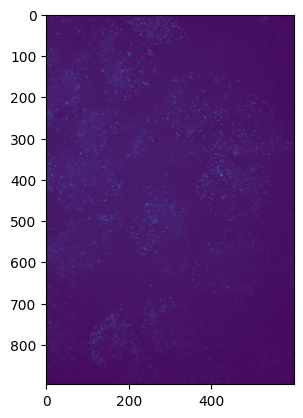

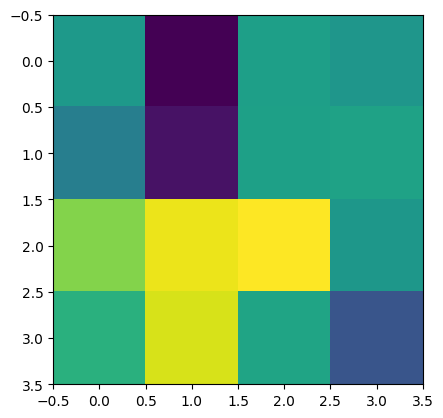

In [ ]:
# TODO For undergrad project spot classification 

# load in image
d = h5_file['raw_images']
# p, t, c, z, y, x
images = da.from_array(d, (1,1,-1,-1,-1,-1))

# display plot
plt.imshow(np.max(images[0, 0, 0, :, :, :], axis=0))
plt.show()

x, y, z = spots.iloc[6][['x_px', 'y_px', 'z_px']]


plt.imshow(np.max(images[0, 0, 0, :, y-2:y+2, x-2:x+2], axis=0))
plt.show()

